## 1_ Installation des dépendances

In [2]:
!pip install nltk pandas scikit-learn matplotlib seaborn pyspark==3.4.0 joblib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 6.8 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 8.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 799.8/799.8 kB 7.6 MB/s eta 0:00:0000:0100:01


## 2_ Imports

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# PySpark
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, udf, when
from pyspark.sql.types import StringType
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    Tokenizer, StopWordsRemover,
    HashingTF, IDF
)
from pyspark.ml.classification import (
    NaiveBayes,
    LogisticRegression,
    RandomForestClassifier
)
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

print("Imports OK")

Imports OK


[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/jovyan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/jovyan/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 3_ Démarrage Spark Session

In [31]:
spark = SparkSession.builder \
    .appName("AmazonReviewsML") \
    .master("local[2]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "2") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print(f"Spark version : {spark.version}")
print(f"Master : {spark.sparkContext.master}")

Spark version : 3.4.0
Master : local[2]


## 4_ Chargement des données

In [32]:
# Chargement du CSV
df = spark.read.csv(
    "/home/jovyan/work/data/Reviews.csv",
    header=True,
    inferSchema=True,
    escape='"'
)

print(f"Nombre total d'avis : {df.count():,}")
print(f"Colonnes : {df.columns}")
df.show(3)

Nombre total d'avis : 568,454
Colonnes : ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']
+---+----------+--------------+--------------------+--------------------+----------------------+-----+----------+--------------------+--------------------+
| Id| ProductId|        UserId|         ProfileName|HelpfulnessNumerator|HelpfulnessDenominator|Score|      Time|             Summary|                Text|
+---+----------+--------------+--------------------+--------------------+----------------------+-----+----------+--------------------+--------------------+
|  1|B001E4KFG0|A3SGXH7AUHU8GW|          delmartian|                   1|                     1|    5|1303862400|Good Quality Dog ...|I have bought sev...|
|  2|B00813GRG4|A1D87F6ZCVE5NK|              dll pa|                   0|                     0|    1|1346976000|   Not as Advertised|Product arrived l...|
|  3|B000LQOCH0| ABXLMWJIXXAIN|Natalia Corres "N

## 5_ Exploration des données

=== Distribution des scores ===
Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64


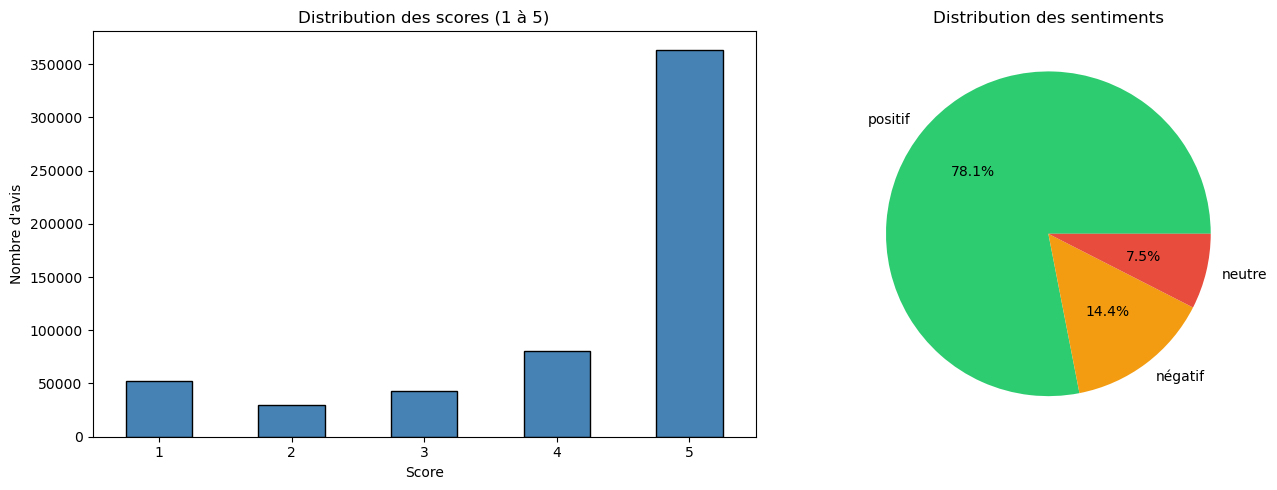

Graphiques sauvegardés


In [4]:
# Convertir en Pandas pour la visualisation
df_pandas = df.select("Score", "Text", "Summary", "ProductId", "Time").toPandas()

print("=== Distribution des scores ===")
print(df_pandas["Score"].value_counts().sort_index())

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution des scores
df_pandas["Score"].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title("Distribution des scores (1 à 5)")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Nombre d'avis")
axes[0].tick_params(rotation=0)

# Distribution des labels (après règle métier)
labels = df_pandas["Score"].apply(
    lambda x: "positif" if x > 3 else ("neutre" if x == 3 else "négatif")
)
labels.value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=['#2ecc71', '#f39c12', '#e74c3c']
)
axes[1].set_title("Distribution des sentiments")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("/home/jovyan/work/data/distribution.png", dpi=150)
plt.show()
print("Graphiques sauvegardés")

## 6_ Création des labels (cible)

In [33]:
# Règles :
# Score < 3  → 0 (négatif)
# Score == 3 → 1 (neutre)
# Score > 3  → 2 (positif)

df = df.withColumn(
    "label_str",
    when(col("Score") < 3, "negative")
    .when(col("Score") == 3, "neutral")
    .otherwise("positive")
)

df = df.withColumn(
    "label",
    when(col("Score") < 3, 0)
    .when(col("Score") == 3, 1)
    .otherwise(2)
)

print("=== Distribution des labels ===")
df.groupBy("label_str").count().orderBy("label_str").show()

=== Distribution des labels ===
+---------+------+
|label_str| count|
+---------+------+
| negative| 82037|
|  neutral| 42640|
| positive|443777|
+---------+------+



## 7_ Nettoyage et Lemmatisation

In [34]:
# Lemmatiseur NLTK
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_and_lemmatize(text):
    if text is None:
        return ""
    
    # 1. Mise en minuscules
    text = text.lower()
    
    # 2. Protéger les négations avant tokenisation
    #    Remplace "not good" par "not_good" (idem pour no, never)
    text = re.sub(r'\bnot\s+(\w+)', r'not_\1', text)
    text = re.sub(r'\bno\s+(\w+)', r'no_\1', text)
    text = re.sub(r'\bnever\s+(\w+)', r'never_\1', text)
    
    # 3. Supprimer la ponctuation et les chiffres, mais garder les underscores
    text = re.sub(r'[^a-zA-Z\s_]', '', text)
    
    # 4. Remplacer les espaces multiples
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 5. Tokenisation
    tokens = text.split()
    
    # 6. Supprimer les stopwords (stop_words d'origine, sans exclure not/no/never)
    #    car ils sont maintenant fusionnés en not_mot, no_mot, never_mot
    tokens = [word for word in tokens if word not in stop_words]
    
    # 7. Supprimer les mots trop courts (longueur <= 2)
    tokens = [word for word in tokens if len(word) > 2]
    
    # 8. Lemmatisation
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    return ' '.join(tokens)

# Enregistrer comme UDF Spark
clean_udf = udf(clean_and_lemmatize, StringType())

# Appliquer sur la colonne Text
df = df.withColumn("clean_text", clean_udf(col("Text")))

# Supprimer les lignes vides
df = df.filter(col("clean_text") != "")

# Sélectionner les colonnes utiles
df_clean = df.select(
    "Id", "ProductId", "UserId",
    "Score", "Time", "Summary",
    "Text", "clean_text",
    "label_str", "label"
)

print("Nettoyage terminé")
df_clean.select("Text", "clean_text", "label_str").show(3, truncate=50)

Nettoyage terminé
+--------------------------------------------------+--------------------------------------------------+---------+
|                                              Text|                                        clean_text|label_str|
+--------------------------------------------------+--------------------------------------------------+---------+
|I have bought several of the Vitality canned do...|bought several vitality canned dog food product...| positive|
|Product arrived labeled as Jumbo Salted Peanuts...|product arrived labeled jumbo salted peanutsthe...| negative|
|This is a confection that has been around a few...|confection around century light pillowy citrus ...| positive|
+--------------------------------------------------+--------------------------------------------------+---------+
only showing top 3 rows



## 8_ Split 80 / 10 / 10

In [35]:
# Split
train_data, val_data, test_data = df_clean.randomSplit(
    [0.8, 0.1, 0.1],
    seed=42
)

print("Split terminé")
print(f"Train   : {train_data.count():,} avis  (80%)")
print(f"Val     : {val_data.count():,} avis  (10%)")
print(f"Test    : {test_data.count():,} avis  (10%)")

# Sauvegarder le test set (utilisé pour le mode online et offline)
test_data.write.mode("overwrite").parquet(
    "/home/jovyan/work/data/test_data.parquet"
)
print("Test set sauvegardé")

Split terminé
Train   : 454,648 avis  (80%)
Val     : 56,535 avis  (10%)
Test    : 57,263 avis  (10%)
Test set sauvegardé


## 9_ Pipeline TF-IDF + Modèles

In [38]:
# ─── Pipeline commun (Tokenizer → StopWords → TF → IDF) ───

tokenizer = Tokenizer(inputCol="clean_text", outputCol="words")

remover = StopWordsRemover(
    inputCol="words",
    outputCol="filtered_words"
)

hashingTF = HashingTF(
    inputCol="filtered_words",
    outputCol="raw_features",
    numFeatures=10000
)

idf = IDF(
    inputCol="raw_features",
    outputCol="features",
    minDocFreq=5
)

# ─── 3 modèles à comparer ─────────────────────────────────

models = {
    "NaiveBayes": NaiveBayes(
        featuresCol="features",
        labelCol="label",
        smoothing=1.0
    ),
    "LogisticRegression": LogisticRegression(
        featuresCol="features",
        labelCol="label",
        maxIter=100,
        regParam=0.01
    ),
    "RandomForest": RandomForestClassifier(
        featuresCol="features",
        labelCol="label",
        numTrees=100,
        seed=42
    )
}

evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

print("Pipeline et modèles configurés")

Pipeline et modèles configurés


## 10_ Entraînement et validation

In [39]:
results = {}

for model_name, classifier in models.items():
    print(f" Entraînement : {model_name}...")

    # Construire le pipeline complet
    pipeline = Pipeline(stages=[
        tokenizer, remover, hashingTF, idf, classifier
    ])

    # Entraîner sur 80%
    trained_model = pipeline.fit(train_data)

    # Valider sur 10%
    val_predictions = trained_model.transform(val_data)
    val_accuracy = evaluator.evaluate(val_predictions)
    val_f1 = evaluator_f1.evaluate(val_predictions)

    results[model_name] = {
        "model": trained_model,
        "val_accuracy": val_accuracy,
        "val_f1": val_f1
    }

    print(f"    Accuracy (val) : {val_accuracy:.4f}")
    print(f"    F1-score (val) : {val_f1:.4f}")

print("=== Résumé validation ===")
for name, res in results.items():
    print(f"{name:25s} | Accuracy: {res['val_accuracy']:.4f} | F1: {res['val_f1']:.4f}")

 Entraînement : NaiveBayes...
    Accuracy (val) : 0.7641
    F1-score (val) : 0.7921
 Entraînement : LogisticRegression...
    Accuracy (val) : 0.8672
    F1-score (val) : 0.8510
 Entraînement : RandomForest...
    Accuracy (val) : 0.7833
    F1-score (val) : 0.6886
=== Résumé validation ===
NaiveBayes                | Accuracy: 0.7641 | F1: 0.7921
LogisticRegression        | Accuracy: 0.8672 | F1: 0.8510
RandomForest              | Accuracy: 0.7833 | F1: 0.6886


## 11_ Ajustement hyperparamètres (meilleur modèle)

In [40]:
# On ajuste le modèle avec la meilleure accuracy sur validation
best_name = max(results, key=lambda x: results[x]['val_accuracy'])
print(f" Meilleur modèle : {best_name}")

# Exemple d'ajustement pour LogisticRegression
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label"
)

pipeline_lr = Pipeline(stages=[tokenizer, remover, hashingTF, idf, lr])

paramGrid = ParamGridBuilder() \
    .addGrid(lr.regParam, [0.01, 0.1]) \
    .addGrid(lr.maxIter, [50, 100]) \
    .build()

crossval = CrossValidator(
    estimator=pipeline_lr,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3,
    seed=42
)

print(" CrossValidation en cours (patience)...")
cv_model = crossval.fit(train_data)
print(f" Meilleur score CV : {max(cv_model.avgMetrics):.4f}")

 Meilleur modèle : LogisticRegression
 CrossValidation en cours (patience)...
 Meilleur score CV : 0.8631


## 12_ Test final & choix du meilleur modèle

In [41]:
print("=== Évaluation finale sur TEST SET (10%) ===\n")

final_results = {}

for model_name, res in results.items():
    test_predictions = res["model"].transform(test_data)
    test_accuracy = evaluator.evaluate(test_predictions)
    test_f1 = evaluator_f1.evaluate(test_predictions)
    final_results[model_name] = {
        "model": res["model"],
        "test_accuracy": test_accuracy,
        "test_f1": test_f1
    }
    print(f"{model_name:25s} | Accuracy: {test_accuracy:.4f} | F1: {test_f1:.4f}")

# Sélection du meilleur
best_model_name = max(
    final_results, key=lambda x: final_results[x]['test_accuracy']
)
best_model = final_results[best_model_name]["model"]

print(f"   Meilleur modèle final : {best_model_name}")
print(f"   Accuracy : {final_results[best_model_name]['test_accuracy']:.4f}")
print(f"   F1-score : {final_results[best_model_name]['test_f1']:.4f}")

=== Évaluation finale sur TEST SET (10%) ===

NaiveBayes                | Accuracy: 0.7674 | F1: 0.7945
LogisticRegression        | Accuracy: 0.8668 | F1: 0.8503
RandomForest              | Accuracy: 0.7821 | F1: 0.6869
   Meilleur modèle final : LogisticRegression
   Accuracy : 0.8668
   F1-score : 0.8503


## 13_ Visualisation des résultats

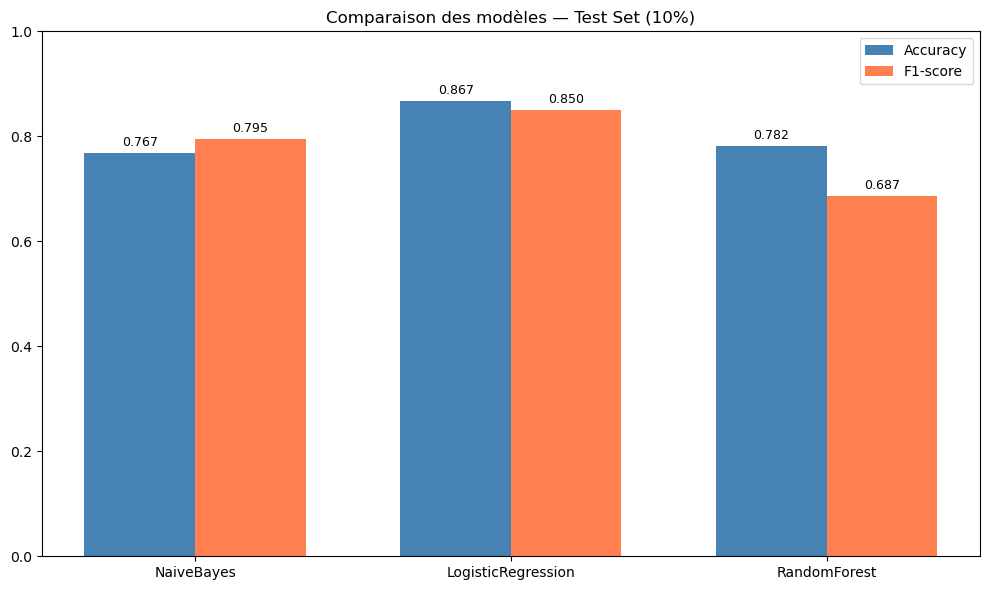

In [42]:
names = list(final_results.keys())
accuracies = [final_results[n]["test_accuracy"] for n in names]
f1_scores = [final_results[n]["test_f1"] for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, f1_scores, width, label='F1-score', color='coral')

ax.set_title("Comparaison des modèles — Test Set (10%)")
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylim(0, 1)
ax.legend()

for bar in bars1 + bars2:
    ax.annotate(
        f'{bar.get_height():.3f}',
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 3), textcoords="offset points",
        ha='center', va='bottom', fontsize=9
    )

plt.tight_layout()
plt.savefig("/home/jovyan/work/data/model_comparison.png", dpi=150)
plt.show()

## 14_ Sauvegarde du meilleur modèle

In [43]:
model_path = "/home/jovyan/work/models/best_model"

# Supprimer si déjà existant
import shutil
if os.path.exists(model_path):
    shutil.rmtree(model_path)

# Sauvegarder
best_model.save(model_path)

# Sauvegarder les métadonnées
metadata = {
    "model_name": best_model_name,
    "test_accuracy": final_results[best_model_name]["test_accuracy"],
    "test_f1": final_results[best_model_name]["test_f1"],
    "label_mapping": {
        "0": "negative",
        "1": "neutral",
        "2": "positive"
    }
}

import json
with open("/home/jovyan/work/models/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"✅ Modèle '{best_model_name}' sauvegardé dans : {model_path}")
print(f"✅ Métadonnées sauvegardées")
print(json.dumps(metadata, indent=2))

✅ Modèle 'LogisticRegression' sauvegardé dans : /home/jovyan/work/models/best_model
✅ Métadonnées sauvegardées
{
  "model_name": "LogisticRegression",
  "test_accuracy": 0.8667726105862424,
  "test_f1": 0.850316119727958,
  "label_mapping": {
    "0": "negative",
    "1": "neutral",
    "2": "positive"
  }
}
